# Projet Deep Learning — Reconnaissance d'expressions faciales

Fondamentaux du Deep Learning — 2026-2027
Équipe : Nathan Le Nestour, YU Xinyu

**Objectif :** reconnaître l'expression d'un visage (7 classes : colère, dégoût, peur, joie, neutre, tristesse, surprise) avec un réseau de neurones convolutif.

**Plan :**
1. Données
2. Modèle de référence (MLP)
3. CNN
4. Entraînement
5. Évaluation et analyse des erreurs
6. Expériences et évaluation finale sur le jeu de test



In [ ]:
!pip -q install kagglehub

In [ ]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
import keras
from keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

keras.utils.set_random_seed(42)   # pour avoir des résultats reproductibles
print('TensorFlow', tf.__version__, '| Keras', keras.__version__)
print('GPU :', tf.config.list_physical_devices('GPU'))

TensorFlow 2.21.0 | Keras 3.13.2
GPU : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/projet_dl_expressions'   # dossier où on sauvegarde les modèles
os.makedirs(SAVE_DIR + '/models', exist_ok=True)
os.makedirs(SAVE_DIR + '/histories', exist_ok=True)

Mounted at /content/drive


---
# 1. Données

## 1.1 Le dataset FER-2013

* **Source :** https://www.kaggle.com/datasets/msambare/fer2013 (version en images du dataset FER-2013).
* **Auteurs :** dataset créé par Pierre-Luc Carrier et Aaron Courville pour un concours Kaggle de 2013 (Goodfellow *et al.*, « Challenges in Representation Learning: A report on three machine learning contests », 2013).
* **Licence :** Open Database License (ODbL), indiquée sur Kaggle.
* **Contenu :** des visages en niveaux de gris de 48×48 pixels, au format `.jpg`, rangés dans un dossier par classe (`train/` et `test/`).
* **Classes :** angry, disgust, fear, happy, neutral, sad, surprise.

Nous avons choisi ce dataset parce que ses 7 classes correspondent au sujet, que les images sont petites (entraînement rapide sur Colab) et que c'est un dataset très utilisé, donc on peut comparer nos résultats (la précision humaine est d'environ 65 %).

In [ ]:
import kagglehub
chemin = kagglehub.dataset_download('msambare/fer2013')
TRAIN_DIR = os.path.join(chemin, 'train')
TEST_DIR = os.path.join(chemin, 'test')

CLASSES = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']   # noms des dossiers
NOMS = ['Colère', 'Dégoût', 'Peur', 'Joie', 'Neutre', 'Tristesse', 'Surprise']

comptes = pd.DataFrame({
    'train': [len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in CLASSES],
    'test':  [len(os.listdir(os.path.join(TEST_DIR, c))) for c in CLASSES],
}, index=NOMS)
comptes['total'] = comptes['train'] + comptes['test']
comptes['% du total'] = (100 * comptes['total'] / comptes['total'].sum()).round(1)
print("Nombre total d'images :", comptes['total'].sum())
comptes

Using Colab cache for faster access to the 'fer2013' dataset.
Nombre total d'images : 35887


,train,test,total,% du total
Colère,3995,958,4953,13.8
Dégoût,436,111,547,1.5
Peur,4097,1024,5121,14.3
Joie,7215,1774,8989,25.0
Neutre,4965,1233,6198,17.3
Tristesse,4830,1247,6077,16.9
Surprise,3171,831,4002,11.2


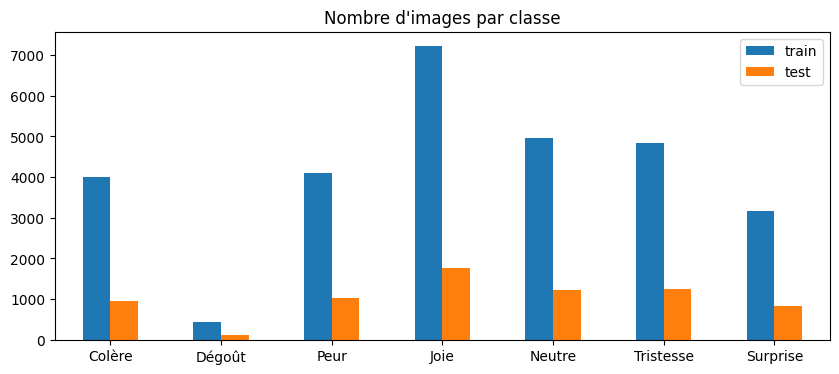

Rapport classe la plus fréquente / la plus rare : 16.4


In [ ]:
comptes[['train', 'test']].plot.bar(figsize=(10, 4), rot=0)
plt.title("Nombre d'images par classe")
plt.show()
print('Rapport classe la plus fréquente / la plus rare :', round(comptes['total'].max() / comptes['total'].min(), 1))

## 1.2 Chargement et prétraitement des images

Chaque image passe par la fonction `preprocess` :
* conversion en **niveaux de gris** (1 canal) ;
* **redimensionnement** en 48×48 ;
* **normalisation** : on divise les pixels par 255 pour avoir des valeurs entre 0 et 1, ce qui rend l'entraînement plus stable.

In [ ]:
def preprocess(img):
    img = img.convert('L').resize((48, 48))
    return np.array(img, dtype=np.float32)[..., np.newaxis] / 255.0   # forme (48, 48, 1)


def charger(dossier):
    X, y = [], []
    tailles, modes = set(), set()
    for k, classe in enumerate(CLASSES):
        for fichier in sorted(os.listdir(os.path.join(dossier, classe))):
            img = Image.open(os.path.join(dossier, classe, fichier))
            tailles.add(img.size)
            modes.add(img.mode)
            X.append(preprocess(img))
            y.append(k)                     # le label est le numéro de la classe (0 à 6)
    print(dossier, '| tailles :', tailles, '| modes :', modes)
    return np.array(X), np.array(y)


X_train_full, y_train_full = charger(TRAIN_DIR)
X_test, y_test = charger(TEST_DIR)
print('train :', X_train_full.shape, '| test :', X_test.shape)

/kaggle/input/fer2013/train | tailles : {(48, 48)} | modes : {'L'}
/kaggle/input/fer2013/test | tailles : {(48, 48)} | modes : {'L'}
train : (28709, 48, 48, 1) | test : (7178, 48, 48, 1)


Toutes les images font 48×48 pixels et sont en mode `L` (niveaux de gris sur 8 bits).

## 1.3 Exemples d'images

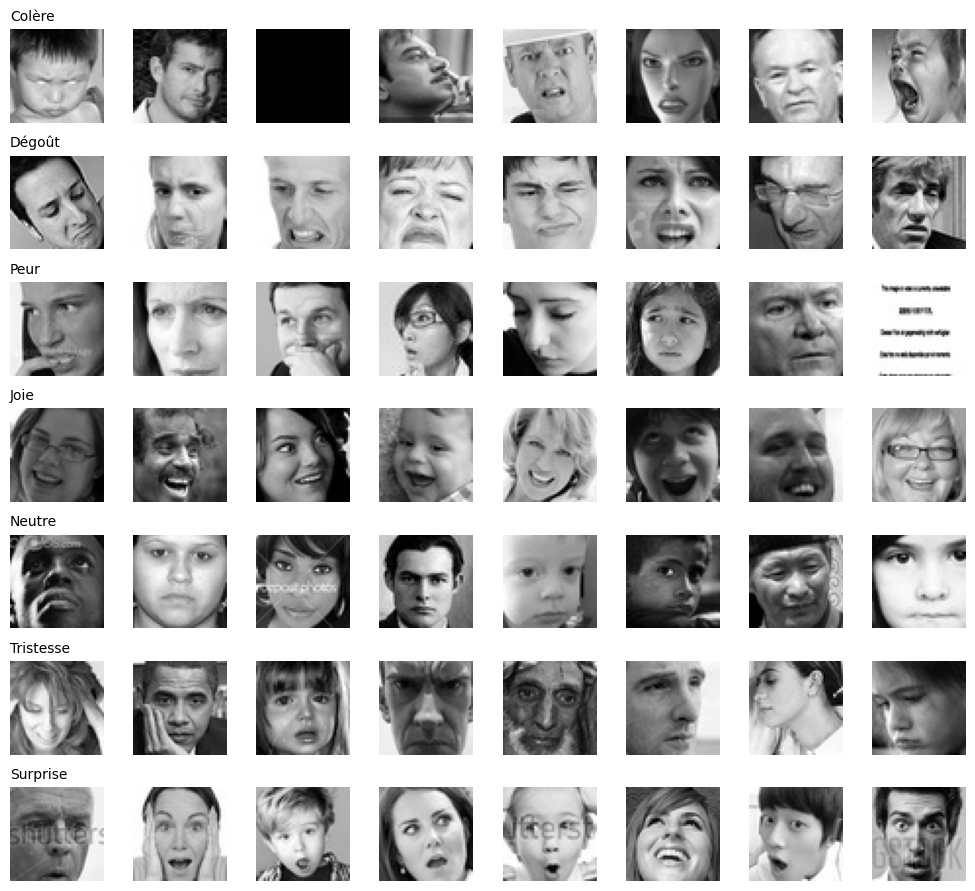

In [ ]:
fig, axes = plt.subplots(7, 8, figsize=(10, 9))
for k in range(7):
    indices = np.where(y_train_full == k)[0][:8]
    for j, i in enumerate(indices):
        axes[k, j].imshow(X_train_full[i].squeeze(), cmap='gray')
        axes[k, j].axis('off')
    axes[k, 0].set_title(NOMS[k], loc='left', fontsize=10)
plt.tight_layout()
plt.show()

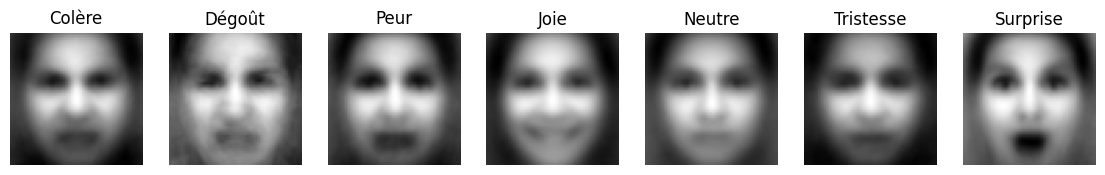

In [ ]:
# visage moyen de chaque classe
fig, axes = plt.subplots(1, 7, figsize=(14, 2.5))
for k in range(7):
    axes[k].imshow(X_train_full[y_train_full == k].mean(axis=0).squeeze(), cmap='gray')
    axes[k].set_title(NOMS[k])
    axes[k].axis('off')
plt.show()

> **Analyse :** Le dataset est déséquilibré : la classe Joie est la plus représentée, alors que la classe Dégoût contient beaucoup moins d'images. Cela peut rendre l'apprentissage plus difficile pour les classes rares. Les images sont petites (48×48) et certaines expressions sont visuellement assez proches, par exemple la peur et la tristesse.

## 1.4 Labels et découpage train / validation / test

* **Encodage one-hot :** le label 3 (Joie) devient `[0, 0, 0, 1, 0, 0, 0]`. C'est le format attendu avec une sortie Softmax à 7 neurones et la perte `categorical_crossentropy`.
* **Découpage :** le dossier `train` est divisé en **85 % entraînement** et **15 % validation**, de façon **stratifiée** (mêmes proportions de classes dans les deux ensembles). Le dossier `test` est gardé à part.
  * entraînement : pour ajuster les poids ;
  * validation : pour suivre l'entraînement, l'arrêter au bon moment et comparer les modèles ;
  * test : utilisé **une seule fois, à la fin**, pour l'évaluation finale.

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, stratify=y_train_full, random_state=42)

Y_train = keras.utils.to_categorical(y_train, 7)
Y_val = keras.utils.to_categorical(y_val, 7)
Y_test = keras.utils.to_categorical(y_test, 7)

print('entraînement :', X_train.shape, '| validation :', X_val.shape, '| test :', X_test.shape)
print('exemple :', y_train[0], '->', Y_train[0])
pd.DataFrame({'train %': np.bincount(y_train) / len(y_train) * 100,
              'validation %': np.bincount(y_val) / len(y_val) * 100}, index=NOMS).round(1)

entraînement : (24402, 48, 48, 1) | validation : (4307, 48, 48, 1) | test : (7178, 48, 48, 1)
exemple : 2 -> [0. 0. 1. 0. 0. 0. 0.]


,train %,validation %
Colère,13.9,13.9
Dégoût,1.5,1.5
Peur,14.3,14.3
Joie,25.1,25.1
Neutre,17.3,17.3
Tristesse,16.8,16.8
Surprise,11.0,11.1


---
# 2. Modèle de référence : un MLP

```
Image 48×48×1 → Flatten (2304) → Dense 256 + ReLU → Dense 128 + ReLU → Dense 7 + Softmax
```

* **Entrée :** `Flatten` transforme l'image 48×48 en un vecteur de 2304 valeurs (un pixel = une entrée).
* **Poids et biais :** chaque neurone calcule $z = \sum_i w_i x_i + b$. Les poids $w_i$ donnent l'importance de chaque entrée, le biais $b$ décale le résultat.
* **Activation :** ReLU, $\max(0, z)$, dans les couches cachées (sans fonction non linéaire, empiler des couches ne servirait à rien). En sortie, Softmax transforme les 7 scores en probabilités qui font 1 au total :
$$\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$$
* **Propagation avant :** on calcule les couches les unes après les autres, de l'entrée jusqu'aux 7 probabilités.
* **Perte :** entropie croisée, $L = -\log(p_{\text{vraie classe}})$. Elle est grande quand le réseau donne une faible probabilité à la bonne classe.
* **Rétropropagation :** on calcule le gradient de la perte par rapport à chaque poids avec la règle de dérivation en chaîne, de la sortie vers l'entrée.
* **Descente de gradient :** on met à jour chaque poids, $w \leftarrow w - \eta \frac{\partial L}{\partial w}$ ($\eta$ = learning rate), sur des mini-batchs de 64 images, avec l'optimiseur Adam.

In [ ]:
# exemple de Softmax
z = np.array([0.8, -0.4, 0.6, 3.1, 1.0, 1.6, 0.6])
p = np.exp(z) / np.exp(z).sum()
print(pd.DataFrame({'score': z, 'probabilité': p.round(3)}, index=NOMS))
print('somme =', p.sum(), '| perte si la vraie classe est Joie :', round(-np.log(p[3]), 3))

           score  probabilité
Colère       0.8        0.061
Dégoût      -0.4        0.018
Peur         0.6        0.050
Joie         3.1        0.610
Neutre       1.0        0.075
Tristesse    1.6        0.136
Surprise     0.6        0.050
somme = 1.0000000000000002 | perte si la vraie classe est Joie : 0.495


### Fonctions utilisées pour tous les modèles

* `entrainer` : compile et entraîne un modèle
* `evaluer` : calcule l'accuracy et la macro-F1.
* `courbes` : affiche l'évolution de la loss et de l'accuracy.

In [ ]:
def entrainer(nom, modele, epochs=60, patience=10, class_weight=None):
    fichier_modele = f'{SAVE_DIR}/models/{nom}.keras'
    fichier_hist = f'{SAVE_DIR}/histories/{nom}.json'
    if os.path.exists(fichier_modele):
        print(nom, ': déjà entraîné, chargé depuis Drive')
        return keras.models.load_model(fichier_modele), json.load(open(fichier_hist))['history']

    modele.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                   loss='categorical_crossentropy', metrics=['accuracy'])
    callbacks = [
        # arrêt quand l'accuracy de validation ne progresse plus, on garde les meilleurs poids
        keras.callbacks.EarlyStopping(monitor='val_accuracy', mode='max', patience=patience, restore_best_weights=True),
        # learning rate divisé par 2 quand la loss de validation stagne
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=patience // 2),
    ]
    h = modele.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=epochs, batch_size=64,
                   class_weight=class_weight, callbacks=callbacks, verbose=2)
    historique = {k: [float(v) for v in valeurs] for k, valeurs in h.history.items()}
    modele.save(fichier_modele)
    json.dump({'history': historique}, open(fichier_hist, 'w'))
    return modele, historique


def evaluer(modele, X, y):
    proba = modele.predict(X, verbose=0)
    y_pred = proba.argmax(axis=1)
    return accuracy_score(y, y_pred), f1_score(y, y_pred, average='macro'), proba


def courbes(h, titre):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h['loss'], label='train')
    ax[0].plot(h['val_loss'], label='validation')
    ax[0].set_title('Loss')
    ax[1].plot(h['accuracy'], label='train')
    ax[1].plot(h['val_accuracy'], label='validation')
    ax[1].set_title('Accuracy')
    for a in ax:
        a.set_xlabel('époque')
        a.legend()
        a.grid(alpha=0.3)
    plt.suptitle(titre)
    plt.show()
    b = int(np.argmax(h['val_accuracy']))
    print(f"meilleure époque : {b + 1} sur {len(h['loss'])} | accuracy train = {h['accuracy'][b]:.3f} | "
          f"accuracy val = {h['val_accuracy'][b]:.3f} | loss val minimale à l'époque {int(np.argmin(h['val_loss'])) + 1}")

In [ ]:
def construire_mlp():
    entree = keras.Input(shape=(48, 48, 1))
    x = layers.Flatten()(entree)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    sortie = layers.Dense(7, activation='softmax')(x)
    return keras.Model(entree, sortie, name='MLP')

construire_mlp().summary()

Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 623,879 (2.38 MB)

 Trainable params: 623,879 (2.38 MB)

 Non-trainable params: 0 (0.00 B)

Nombre de paramètres d'une couche Dense = entrées × neurones + neurones (biais) :
* 2304 × 256 + 256 = 590 080
* 256 × 128 + 128 = 32 896
* 128 × 7 + 7 = 903
* total : **623 879**

Epoch 1/60
382/382 - 8s - 21ms/step - accuracy: 0.2701 - loss: 1.7949 - val_accuracy: 0.3107 - val_loss: 1.7374 - learning_rate: 0.0010
Epoch 2/60
382/382 - 1s - 4ms/step - accuracy: 0.3212 - loss: 1.7115 - val_accuracy: 0.3276 - val_loss: 1.6972 - learning_rate: 0.0010
Epoch 3/60
382/382 - 1s - 3ms/step - accuracy: 0.3390 - loss: 1.6715 - val_accuracy: 0.3299 - val_loss: 1.6866 - learning_rate: 0.0010
Epoch 4/60
382/382 - 1s - 3ms/step - accuracy: 0.3494 - loss: 1.6496 - val_accuracy: 0.3506 - val_loss: 1.6613 - learning_rate: 0.0010
Epoch 5/60
382/382 - 1s - 3ms/step - accuracy: 0.3613 - loss: 1.6259 - val_accuracy: 0.3617 - val_loss: 1.6455 - learning_rate: 0.0010
Epoch 6/60
382/382 - 1s - 3ms/step - accuracy: 0.3717 - loss: 1.6052 - val_accuracy: 0.3538 - val_loss: 1.6405 - learning_rate: 0.0010
Epoch 7/60
382/382 - 1s - 3ms/step - accuracy: 0.3757 - loss: 1.5881 - val_accuracy: 0.3580 - val_loss: 1.6359 - learning_rate: 0.0010
Epoch 8/60
382/382 - 1s - 3ms/step - accuracy: 0.3837 

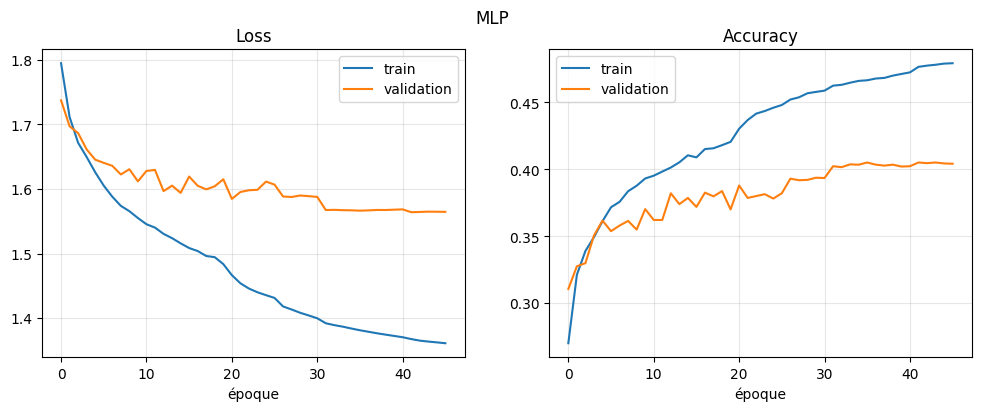

meilleure époque : 36 sur 46 | accuracy train = 0.467 | accuracy val = 0.405 | loss val minimale à l'époque 42
MLP — validation : accuracy = 0.405, macro-F1 = 0.321


In [ ]:
mlp, h_mlp = entrainer('MLP', construire_mlp())
courbes(h_mlp, 'MLP')
acc, f1, _ = evaluer(mlp, X_val, y_val)
print(f'MLP — validation : accuracy = {acc:.3f}, macro-F1 = {f1:.3f}')

### Vérification : propagation avant avec NumPy

On refait le calcul du MLP « à la main » avec ses poids appris, et on compare avec Keras.

In [ ]:
(W1, b1), (W2, b2), (W3, b3) = [c.get_weights() for c in mlp.layers if isinstance(c, layers.Dense)]
x = X_val[0].reshape(-1)                    # Flatten : 2304 valeurs
h1 = np.maximum(0, x @ W1 + b1)             # Dense 256 + ReLU
h2 = np.maximum(0, h1 @ W2 + b2)            # Dense 128 + ReLU
z = h2 @ W3 + b3                            # Dense 7
p_numpy = np.exp(z) / np.exp(z).sum()       # Softmax
p_keras = mlp.predict(X_val[:1], verbose=0)[0]
print('NumPy :', p_numpy.round(3))
print('Keras :', p_keras.round(3))

NumPy : [0.061 0.008 0.12  0.43  0.169 0.185 0.027]
Keras : [0.061 0.008 0.12  0.43  0.169 0.185 0.027]


> **Analyse :** Le MLP obtient une accuracy de 0,410 et un macro-F1 de 0,324 sur la validation. Ces résultats sont assez faibles, surtout pour le macro-F1, ce qui montre que certaines classes sont mal reconnues. L'écart entre l'accuracy d'entraînement (0,479) et celle de validation (0,410) reste limité.
Le MLP utilise directement tous les pixels après le Flatten et ne prend donc pas en compte la structure spatiale de l'image. Cela explique en partie ses performances limitées pour la reconnaissance des expressions faciales.

---
# 3. Construction d'un CNN

## 3.1 Les notions

* **Filtre (noyau) :** petite matrice de poids (ici 3×3) qui détecte un motif local (bord, coin, puis des formes plus complexes). Ses valeurs sont apprises.
* **Convolution :** le filtre glisse sur l'image ; à chaque position on fait la somme des produits entre le filtre et la zone de l'image, plus un biais. Le même filtre est utilisé partout dans l'image (partage des poids), donc il y a peu de paramètres.
* **Feature map :** le résultat d'un filtre sur toute l'image. 32 filtres donnent 32 feature maps.
* **Taille du kernel :** 3×3. Deux convolutions 3×3 à la suite voient une zone de 5×5 avec moins de paramètres qu'un filtre 5×5.
* **Stride :** le pas de déplacement du filtre. Avec 1, on garde la taille ; avec 2, on la divise par 2.
* **Padding :** `same` ajoute des zéros autour de l'image pour garder la même taille ; `valid` n'en ajoute pas (48 → 46 avec un filtre 3×3).
* **ReLU :** met les valeurs négatives à 0.
* **Max pooling 2×2 :** garde le maximum de chaque carré 2×2, donc divise la taille par 2. Pas de paramètres.
* **Flatten :** transforme le dernier tenseur en vecteur pour les couches Dense.
* **Dense et sortie :** les couches Dense combinent les caractéristiques ; la sortie a 7 neurones avec Softmax.

Taille de sortie : $n_{sortie} = \lfloor (n + 2p - k) / s \rfloor + 1$ ($n$ = taille d'entrée, $k$ = kernel, $p$ = padding, $s$ = stride).

### Exemple : une convolution faite à la main
On applique un filtre de Sobel (détecteur de bords horizontaux) à une image, puis ReLU et un max pooling.

valid : (46, 46) | same : (48, 48) | same + stride 2 : (24, 24) | après pooling : (24, 24)


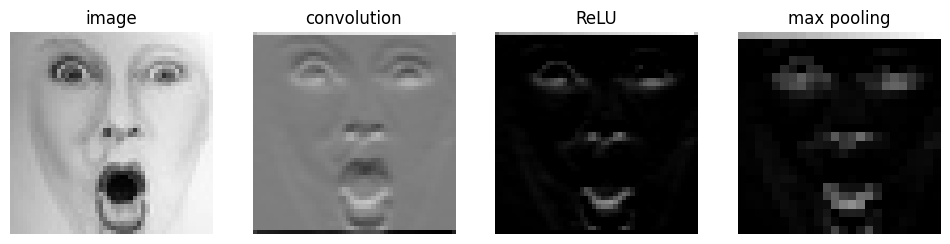

In [ ]:
def convolution(image, filtre, stride=1, padding='valid'):
    k = filtre.shape[0]
    if padding == 'same':
        image = np.pad(image, k // 2)
    n = (image.shape[0] - k) // stride + 1
    sortie = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            zone = image[i * stride:i * stride + k, j * stride:j * stride + k]
            sortie[i, j] = np.sum(zone * filtre)
    return sortie

sobel = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
img = X_train[0].squeeze()
fmap = convolution(img, sobel, padding='same')
fmap_relu = np.maximum(0, fmap)
fmap_pool = fmap_relu.reshape(24, 2, 24, 2).max(axis=(1, 3))     # max pooling 2×2

print('valid :', convolution(img, sobel).shape, '| same :', fmap.shape,
      '| same + stride 2 :', convolution(img, sobel, stride=2, padding='same').shape, '| après pooling :', fmap_pool.shape)
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for a, im, t in zip(axes, [img, fmap, fmap_relu, fmap_pool], ['image', 'convolution', 'ReLU', 'max pooling']):
    a.imshow(im, cmap='gray')
    a.set_title(t)
    a.axis('off')
plt.show()

## 3.2 Architecture proposée

```
Entrée 48×48×1
Bloc 1 : Conv 3×3 (32) + ReLU → Conv 3×3 (32) + ReLU → MaxPool 2×2   → 24×24×32
Bloc 2 : Conv 3×3 (64) + ReLU → Conv 3×3 (64) + ReLU → MaxPool 2×2   → 12×12×64
Bloc 3 : Conv 3×3 (128) + ReLU → Conv 3×3 (128) + ReLU → MaxPool 2×2 → 6×6×128
Flatten (4608) → Dense 256 + ReLU → Dense 7 + Softmax
```

Pourquoi ces choix :
* 3 blocs : la taille passe de 48 à 24, 12 puis 6. Avec un 4e bloc on arriverait à 3×3, ce qui est trop petit.
* 2 convolutions par bloc : plus de non-linéarités et un champ de vision plus grand pour peu de paramètres.
* Le nombre de filtres augmente (32, 64, 128) quand la taille de l'image diminue : les premières couches cherchent des motifs simples, les dernières des motifs plus complexes.
* Padding `same` et stride 1 : seule la couche de pooling réduit la taille.
* Pas de régularisation dans la première version, pour voir d'abord comment le réseau se comporte. Les options `dropout`, `batchnorm`, `augmentation` et `filtres` servent pour les expériences de la partie 6.

In [ ]:
def augmentation():
    return keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.05),          # ± 18 degrés
        layers.RandomTranslation(0.1, 0.1),   # ± 10 %
        layers.RandomZoom(0.1),               # ± 10 %
    ], name='augmentation')


def construire_cnn(filtres=(32, 64, 128), dropout=False, batchnorm=False, augmentation_donnees=False):
    entree = keras.Input(shape=(48, 48, 1))
    x = augmentation()(entree) if augmentation_donnees else entree
    for i, f in enumerate(filtres, start=1):
        for j in (1, 2):
            x = layers.Conv2D(f, 3, padding='same', use_bias=not batchnorm, name=f'conv{i}_{j}')(x)
            if batchnorm:
                x = layers.BatchNormalization()(x)
            x = layers.Activation('relu', name=f'relu{i}_{j}')(x)
        x = layers.MaxPooling2D(2)(x)
        if dropout:
            x = layers.Dropout(0.25)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256)(x)
    if batchnorm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    if dropout:
        x = layers.Dropout(0.5)(x)
    sortie = layers.Dense(7, activation='softmax')(x)
    return keras.Model(entree, sortie)

## 3.3 Dimensions et nombre de paramètres couche par couche

In [ ]:
cnn = construire_cnn()
print(f"{'couche':<16}{'sortie':<18}{'paramètres':>12}")
for c in cnn.layers:
    print(f'{c.name:<16}{str(c.output.shape[1:]):<18}{c.count_params():>12,}')
print(f'total : {cnn.count_params():,} paramètres')

couche          sortie              paramètres
input_layer_2   (48, 48, 1)                  0
conv1_1         (48, 48, 32)               320
relu1_1         (48, 48, 32)                 0
conv1_2         (48, 48, 32)             9,248
relu1_2         (48, 48, 32)                 0
max_pooling2d   (24, 24, 32)                 0
conv2_1         (24, 24, 64)            18,496
relu2_1         (24, 24, 64)                 0
conv2_2         (24, 24, 64)            36,928
relu2_2         (24, 24, 64)                 0
max_pooling2d_1 (12, 12, 64)                 0
conv3_1         (12, 12, 128)           73,856
relu3_1         (12, 12, 128)                0
conv3_2         (12, 12, 128)          147,584
relu3_2         (12, 12, 128)                0
max_pooling2d_2 (6, 6, 128)                  0
flatten_2       (4608,)                      0
dense_6         (256,)               1,179,904
activation      (256,)                       0
dense_7         (7,)                     1,799
total : 1,468

Calcul du nombre de paramètres :
* Conv2D : (k × k × canaux d'entrée + 1) × nombre de filtres. Par exemple conv1_1 : (3×3×1 + 1) × 32 = 320 ; conv1_2 : (3×3×32 + 1) × 32 = 9 248.
* Dense : (entrées + 1) × neurones. Couche Dense 256 : (4608 + 1) × 256 = 1 179 904, soit environ 80 % du total.
* ReLU, MaxPooling et Flatten n'ont pas de paramètres.

---
# 4. Entraînement

| Choix | Valeur | Justification |
|---|---|---|
| Perte | `categorical_crossentropy` | classification multiclasse, labels one-hot, sortie Softmax |
| Optimiseur | Adam, learning rate 0,001 | converge vite sans beaucoup de réglages |
| Batch size | 64 | compromis entre stabilité du gradient et vitesse |
| Époques | 60 maximum + Early Stopping (patience 10) | on s'arrête quand la validation ne progresse plus et on garde la meilleure époque |
| Learning rate | divisé par 2 si la loss de validation stagne | pas plus petits en fin d'entraînement |
| Métriques | accuracy, puis macro-F1 et matrice de confusion | l'accuracy seule ne suffit pas avec des classes déséquilibrées |

Epoch 1/60
382/382 - 26s - 68ms/step - accuracy: 0.2828 - loss: 1.7587 - val_accuracy: 0.3794 - val_loss: 1.5910 - learning_rate: 0.0010
Epoch 2/60
382/382 - 6s - 16ms/step - accuracy: 0.4269 - loss: 1.4826 - val_accuracy: 0.4678 - val_loss: 1.3957 - learning_rate: 0.0010
Epoch 3/60
382/382 - 6s - 15ms/step - accuracy: 0.4983 - loss: 1.3073 - val_accuracy: 0.5120 - val_loss: 1.2938 - learning_rate: 0.0010
Epoch 4/60
382/382 - 6s - 16ms/step - accuracy: 0.5530 - loss: 1.1738 - val_accuracy: 0.5340 - val_loss: 1.2640 - learning_rate: 0.0010
Epoch 5/60
382/382 - 6s - 15ms/step - accuracy: 0.6012 - loss: 1.0540 - val_accuracy: 0.5310 - val_loss: 1.3038 - learning_rate: 0.0010
Epoch 6/60
382/382 - 6s - 15ms/step - accuracy: 0.6544 - loss: 0.9276 - val_accuracy: 0.5291 - val_loss: 1.3680 - learning_rate: 0.0010
Epoch 7/60
382/382 - 6s - 16ms/step - accuracy: 0.7039 - loss: 0.8010 - val_accuracy: 0.5280 - val_loss: 1.6529 - learning_rate: 0.0010
Epoch 8/60
382/382 - 6s - 15ms/step - accuracy:

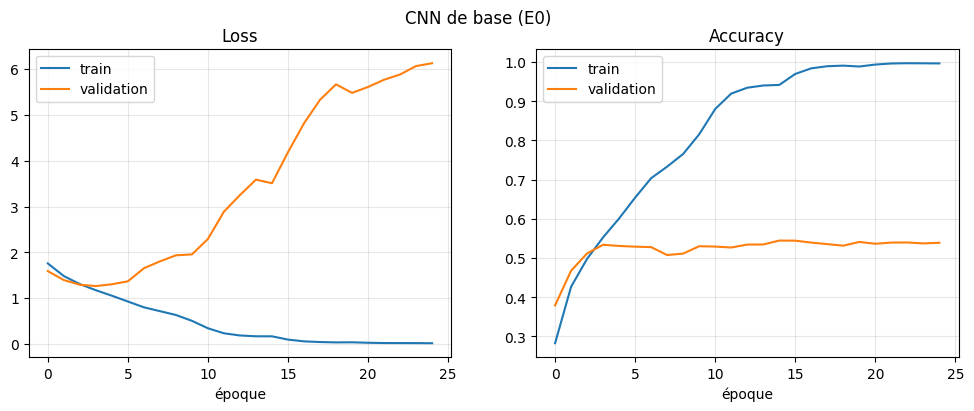

meilleure époque : 15 sur 25 | accuracy train = 0.942 | accuracy val = 0.545 | loss val minimale à l'époque 4
CNN de base — validation : accuracy = 0.545, macro-F1 = 0.519


In [ ]:
cnn_base, h_base = entrainer('E0_cnn_base', construire_cnn())
courbes(h_base, 'CNN de base (E0)')
acc, f1, _ = evaluer(cnn_base, X_val, y_val)
print(f'CNN de base — validation : accuracy = {acc:.3f}, macro-F1 = {f1:.3f}')

> **Analyse :** Le CNN de base obtient une accuracy de validation de 0,547 et un macro-F1 de 0,514. Il est donc nettement meilleur que le MLP (0,410 d'accuracy et 0,324 de macro-F1). Les convolutions permettent de mieux exploiter les informations locales de l'image, comme les yeux, la bouche ou les contours du visage.

Cependant, l'accuracy d'entraînement atteint 0,953 alors que celle de validation est seulement de 0,547. L'écart est très important et montre un fort surapprentissage. Il faut donc ajouter des techniques de régularisation pour améliorer la généralisation du modèle.

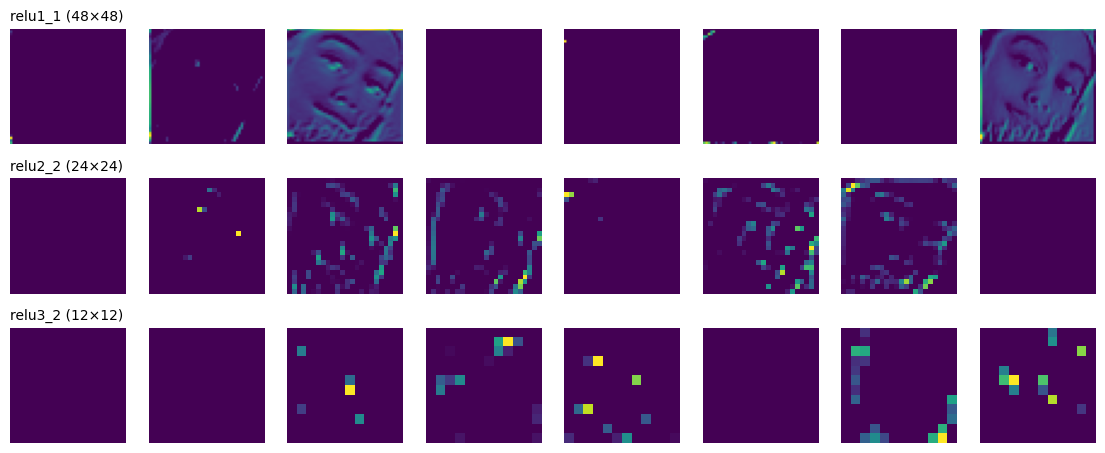

In [ ]:
# feature maps d'une image à trois profondeurs du réseau
noms_couches = ['relu1_1', 'relu2_2', 'relu3_2']
extracteur = keras.Model(cnn_base.inputs, [cnn_base.get_layer(n).output for n in noms_couches])
cartes = extracteur.predict(X_val[:1], verbose=0)

fig, axes = plt.subplots(3, 8, figsize=(14, 5.5))
for r, (nom, fmap) in enumerate(zip(noms_couches, cartes)):
    for c in range(8):
        axes[r, c].imshow(fmap[0, :, :, c], cmap='viridis')
        axes[r, c].axis('off')
    axes[r, 0].set_title(f'{nom} ({fmap.shape[1]}×{fmap.shape[2]})', loc='left', fontsize=10)
plt.show()

---
# 5. Évaluation et analyse des erreurs

On analyse le CNN de base sur le jeu de **validation** (le test est gardé pour la fin).

* **Précision** d'une classe : parmi les images prédites dans cette classe, la proportion correcte.
* **Rappel** : parmi les images de cette classe, la proportion retrouvée.
* **F1** : moyenne harmonique de la précision et du rappel. **Macro-F1** : moyenne des F1 des 7 classes (chaque classe compte autant).
* **Matrice de confusion** : ligne = vraie classe, colonne = classe prédite. Normalisée par ligne, la diagonale donne le rappel.

CNN de base — validation : accuracy = 0.547, macro-F1 = 0.514

              precision    recall  f1-score   support

      Colère      0.453     0.457     0.455       599
      Dégoût      0.479     0.354     0.407        65
        Peur      0.428     0.410     0.419       615
        Joie      0.727     0.774     0.749      1082
      Neutre      0.480     0.518     0.498       745
   Tristesse      0.411     0.383     0.397       725
    Surprise      0.708     0.643     0.674       476

    accuracy                          0.547      4307
   macro avg      0.527     0.506     0.514      4307
weighted avg      0.544     0.547     0.545      4307



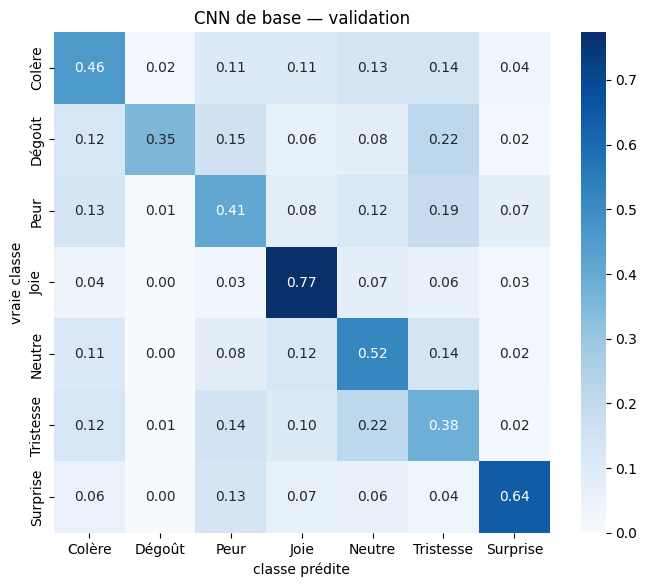

Confusions les plus fréquentes :
  Tristesse prédit Neutre : 22% des cas
  Dégoût prédit Tristesse : 22% des cas
  Peur prédit Tristesse : 19% des cas
  Dégoût prédit Peur : 15% des cas
  Tristesse prédit Peur : 14% des cas


In [ ]:
def rapport(modele, X, y, titre):
    acc, f1, proba = evaluer(modele, X, y)
    y_pred = proba.argmax(axis=1)
    print(f'{titre} : accuracy = {acc:.3f}, macro-F1 = {f1:.3f}\n')
    print(classification_report(y, y_pred, target_names=NOMS, digits=3))
    cm = confusion_matrix(y, y_pred, normalize='true')
    plt.figure(figsize=(8, 6.5))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=NOMS, yticklabels=NOMS)
    plt.xlabel('classe prédite')
    plt.ylabel('vraie classe')
    plt.title(titre)
    plt.show()
    # confusions les plus fréquentes
    paires = [(cm[i, j], NOMS[i], NOMS[j]) for i in range(7) for j in range(7) if i != j]
    print('Confusions les plus fréquentes :')
    for v, vraie, predite in sorted(paires, reverse=True)[:5]:
        print(f'  {vraie} prédit {predite} : {v:.0%} des cas')
    return proba


proba_base = rapport(cnn_base, X_val, y_val, 'CNN de base — validation')

### Exemples : image + vraie classe + classe prédite + probabilité

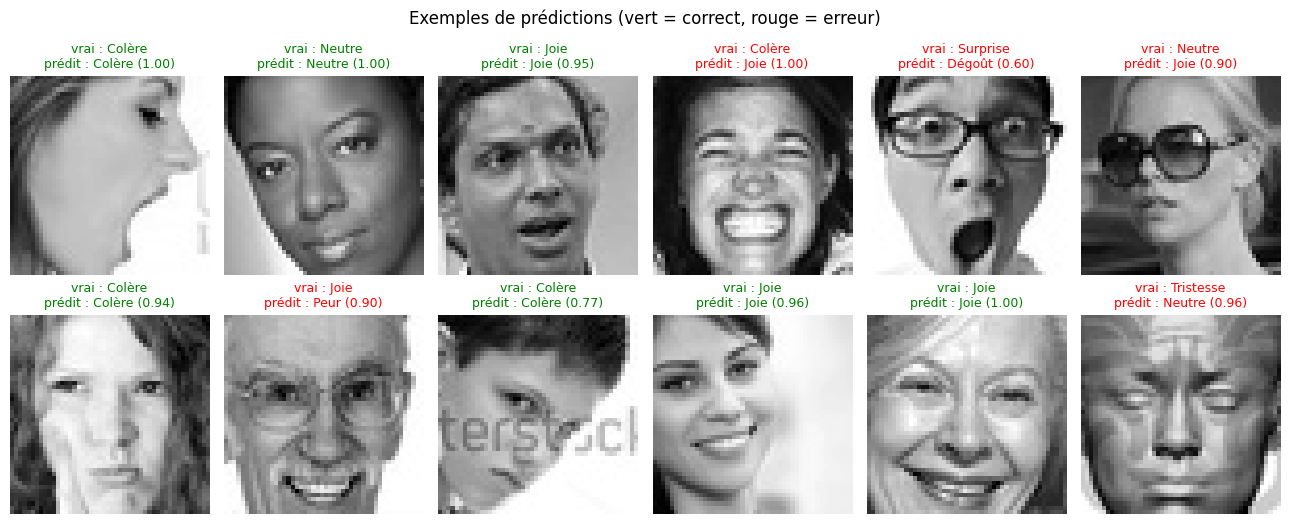

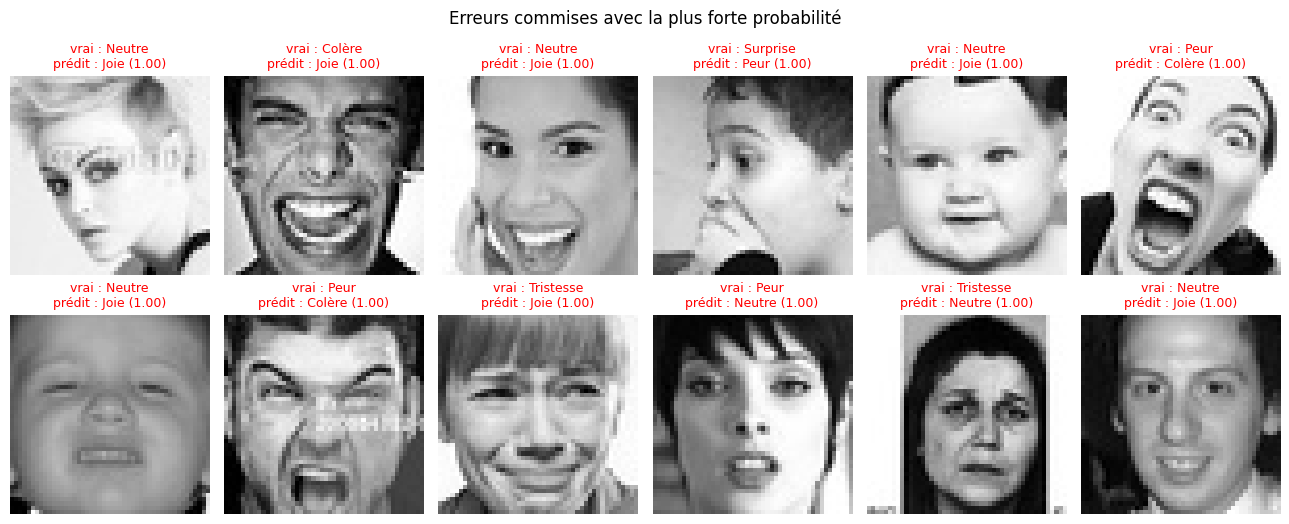

In [ ]:
def afficher(X, y, proba, indices, titre):
    fig, axes = plt.subplots(2, 6, figsize=(13, 5.5))
    for a, i in zip(axes.ravel(), indices):
        k = proba[i].argmax()
        a.imshow(X[i].squeeze(), cmap='gray')
        a.set_title(f'vrai : {NOMS[y[i]]}\nprédit : {NOMS[k]} ({proba[i, k]:.2f})',
                    color='green' if k == y[i] else 'red', fontsize=9)
        a.axis('off')
    plt.suptitle(titre)
    plt.tight_layout()
    plt.show()


afficher(X_val, y_val, proba_base, np.random.default_rng(0).choice(len(X_val), 12, replace=False),
         'Exemples de prédictions (vert = correct, rouge = erreur)')

erreurs = np.where(proba_base.argmax(axis=1) != y_val)[0]
pires = erreurs[np.argsort(proba_base[erreurs].max(axis=1))[::-1][:12]]
afficher(X_val, y_val, proba_base, pires, 'Erreurs commises avec la plus forte probabilité')

> **Analyse :** Les performances sont très différentes selon les expressions. La Joie est la classe la mieux reconnue, avec un F1-score de 0,749, suivie de Surprise avec 0,674. À l'inverse, Dégoût, Peur et Tristesse sont plus difficiles à reconnaître.
Les principales confusions sont entre Tristesse et Neutre, entre Peur et Tristesse, ainsi qu'entre Dégoût et Tristesse ou Peur. Ces expressions peuvent avoir des caractéristiques visuelles proches, surtout avec des images de seulement 48×48 pixels.

---
# 6. Expériences

## 6.1 Expériences E0 à E4

À chaque expérience, on change **une seule chose** par rapport à la précédente :

| Expérience | Modification |
|---|---|
| E0 | CNN de base |
| E1 | E0 + Dropout (0,25 après chaque bloc, 0,5 avant la sortie) |
| E2 | E1 + Batch Normalization |
| E3 | E2 + Data Augmentation (miroir, rotation, translation, zoom) |
| E4 | E3 avec 2 fois plus de filtres (64, 128, 256) |
| E5 | meilleur modèle de E0 à E4 + pondération des classes |

Avec la Data Augmentation l'entraînement est plus long, on autorise donc 80 époques (patience 12).

In [ ]:
configs = {
    'E0_cnn_base': {},
    'E1_dropout': dict(dropout=True),
    'E2_dropout_bn': dict(dropout=True, batchnorm=True),
    'E3_augmentation': dict(dropout=True, batchnorm=True, augmentation_donnees=True),
    'E4_filtres_x2': dict(dropout=True, batchnorm=True, augmentation_donnees=True, filtres=(64, 128, 256)),
}

modeles = {'MLP': mlp, 'E0_cnn_base': cnn_base}
historiques = {'MLP': h_mlp, 'E0_cnn_base': h_base}
for nom, cfg in configs.items():
    if nom not in modeles:
        aug = cfg.get('augmentation_donnees', False)
        modeles[nom], historiques[nom] = entrainer(nom, construire_cnn(**cfg),
                                                   epochs=80 if aug else 60, patience=12 if aug else 10)

E1_dropout : déjà entraîné, chargé depuis Drive
E2_dropout_bn : déjà entraîné, chargé depuis Drive
E3_augmentation : déjà entraîné, chargé depuis Drive
E4_filtres_x2 : déjà entraîné, chargé depuis Drive


In [ ]:
def tableau_resultats():
    lignes = []
    for nom, modele in modeles.items():
        acc, f1, _ = evaluer(modele, X_val, y_val)
        h = historiques[nom]
        b = int(np.argmax(h['val_accuracy']))
        lignes.append({'modèle': nom, 'paramètres': modele.count_params(), 'époques': len(h['loss']),
                       'accuracy train': h['accuracy'][b], 'accuracy val': acc, 'macro-F1 val': f1,
                       'écart train - val': h['accuracy'][b] - acc})
    return pd.DataFrame(lignes).set_index('modèle').round(3)

tableau = tableau_resultats()
tableau

,paramètres,époques,accuracy train,accuracy val,macro-F1 val,écart train - val
modèle,,,,,,
MLP,623879,51,0.479,0.410,0.324,0.068
E0_cnn_base,1468135,25,0.953,0.547,0.514,0.406
E1_dropout,1468135,38,0.734,0.606,0.577,0.129
E2_dropout_bn,1470503,53,0.895,0.647,0.623,0.248
E3_augmentation,1470503,52,0.639,0.632,0.568,0.006
E4_filtres_x2,3509319,61,0.717,0.661,0.612,0.056


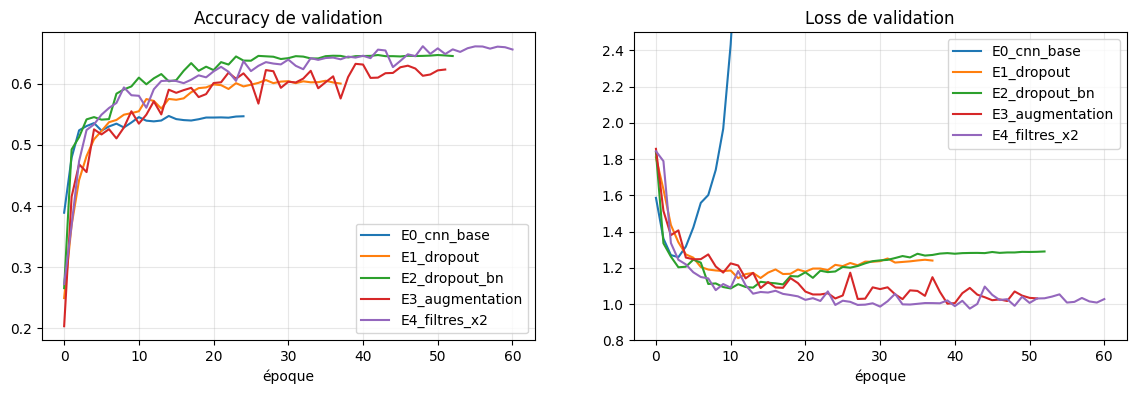

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for nom in configs:
    ax[0].plot(historiques[nom]['val_accuracy'], label=nom)
    ax[1].plot(historiques[nom]['val_loss'], label=nom)
ax[0].set_title('Accuracy de validation')
ax[1].set_title('Loss de validation')
ax[1].set_ylim(0.8, 2.5)
for a in ax:
    a.set_xlabel('époque')
    a.legend()
    a.grid(alpha=0.3)
plt.show()

> **Analyse :** Les expériences montrent que les différentes modifications ont un effet important sur les performances. L'ajout du Dropout dans E1 augmente l'accuracy de 0,547 à 0,606 et réduit fortement l'écart entre entraînement et validation. Il permet donc de limiter le surapprentissage.

Avec la Batch Normalization, E2 atteint 0,647 d'accuracy et 0,623 de macro-F1. La Data Augmentation de E3 réduit presque complètement l'écart entre entraînement et validation, mais les performances diminuent légèrement avec une accuracy de 0,632. Enfin, E4 augmente le nombre de filtres et obtient la meilleure accuracy, avec 0,661, tout en gardant un faible écart entre entraînement et validation.

E4 donne donc la meilleure accuracy, mais E2 conserve le meilleur macro-F1 parmi E0 à E4.

## 6.2 E5 : pondération des classes

On reprend le meilleur modèle de E0 à E4 (accuracy de validation) et on ajoute un poids par classe, pour que les erreurs sur les classes rares comptent plus dans la perte. On utilise la racine carrée des poids « balanced » : $w_k = \sqrt{N / (7 \times N_k)}$ ($N_k$ = nombre d'images de la classe $k$). Sans la racine, Dégoût aurait un poids environ 16 fois plus grand que Joie, ce qui est trop.

In [ ]:
base = tableau.loc[list(configs), 'accuracy val'].idxmax()
print('Meilleur modèle de E0 à E4 :', base)

n = np.bincount(y_train)
poids = {k: float(np.sqrt(len(y_train) / (7 * n[k]))) for k in range(7)}
print(pd.DataFrame({'images': n, 'poids': np.round(list(poids.values()), 2)}, index=NOMS).T)

modeles['E5_class_weight'], historiques['E5_class_weight'] = entrainer(
    'E5_class_weight', construire_cnn(**configs[base]), epochs=80, patience=12, class_weight=poids)

Meilleur modèle de E0 à E4 : E4_filtres_x2
         Colère  Dégoût    Peur     Joie   Neutre  Tristesse  Surprise
images  3396.00  371.00  3482.0  6133.00  4220.00    4105.00   2695.00
poids      1.01    3.07     1.0     0.75     0.91       0.92      1.14
E5_class_weight : déjà entraîné, chargé depuis Drive


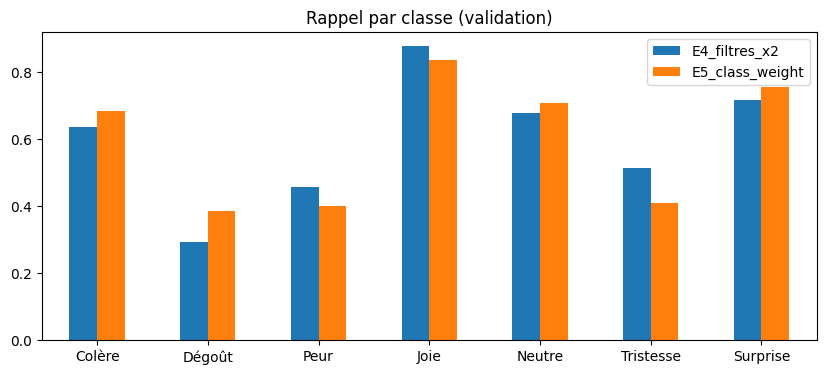

,Colère,Dégoût,Peur,Joie,Neutre,Tristesse,Surprise
E4_filtres_x2,0.64,0.29,0.46,0.88,0.68,0.51,0.72
E5_class_weight,0.68,0.38,0.40,0.84,0.71,0.41,0.75


In [ ]:
def rappel_par_classe(modele):
    y_pred = modele.predict(X_val, verbose=0).argmax(axis=1)
    return np.diag(confusion_matrix(y_val, y_pred, normalize='true'))

rappels = pd.DataFrame({base: rappel_par_classe(modeles[base]),
                        'E5_class_weight': rappel_par_classe(modeles['E5_class_weight'])}, index=NOMS)
rappels.plot.bar(figsize=(10, 4), rot=0)
plt.title('Rappel par classe (validation)')
plt.show()
rappels.T.round(2)

## 6.3 Tableau comparatif et choix du modèle final

On choisit le modèle qui a la meilleure **macro-F1 sur la validation**, parce que chaque expression doit être bien reconnue, y compris les classes rares. Le choix se fait uniquement sur la validation.

In [ ]:
tableau = tableau_resultats()
display(tableau)

nom_final = tableau.drop('MLP')['macro-F1 val'].idxmax()
modele_final = modeles[nom_final]
print('Modèle final :', nom_final)

,paramètres,époques,accuracy train,accuracy val,macro-F1 val,écart train - val
modèle,,,,,,
MLP,623879,51,0.479,0.410,0.324,0.068
E0_cnn_base,1468135,25,0.953,0.547,0.514,0.406
E1_dropout,1468135,38,0.734,0.606,0.577,0.129
E2_dropout_bn,1470503,53,0.895,0.647,0.623,0.248
E3_augmentation,1470503,52,0.639,0.632,0.568,0.006
E4_filtres_x2,3509319,61,0.717,0.661,0.612,0.056
E5_class_weight,3509319,42,0.637,0.642,0.597,-0.005


Modèle final : E2_dropout_bn


> **Analyse :** La pondération des classes améliore le rappel de certaines classes, notamment Dégoût, qui passe de 0,29 avec E4 à 0,38 avec E5. Le rappel augmente aussi pour Colère, Neutre et Surprise. En revanche, il diminue pour Peur, Joie et surtout Tristesse.

Au niveau global, E5 obtient une accuracy de 0,642 et un macro-F1 de 0,597, ce qui est inférieur à E4 et à E2. La pondération aide donc certaines classes mais ne permet pas d'améliorer les performances générales.

Nous choisissons finalement E2 (Dropout + Batch Normalization), car il obtient le meilleur macro-F1 sur le jeu de validation avec 0,623. Cette métrique est importante ici car elle donne le même poids aux sept expressions, même lorsque les classes sont déséquilibrées.

## 6.4 Évaluation finale sur le jeu de test

Le modèle final est évalué **une seule fois** sur le jeu de test (7 178 images jamais utilisées avant). On évalue aussi le MLP et le CNN de base sur le même jeu pour comparer.

Modèle final (E2_dropout_bn) — test : accuracy = 0.655, macro-F1 = 0.643

              precision    recall  f1-score   support

      Colère      0.585     0.554     0.569       958
      Dégoût      0.774     0.586     0.667       111
        Peur      0.544     0.454     0.495      1024
        Joie      0.826     0.856     0.841      1774
      Neutre      0.588     0.647     0.616      1233
   Tristesse      0.513     0.532     0.522      1247
    Surprise      0.788     0.800     0.794       831

    accuracy                          0.655      7178
   macro avg      0.660     0.633     0.643      7178
weighted avg      0.653     0.655     0.653      7178



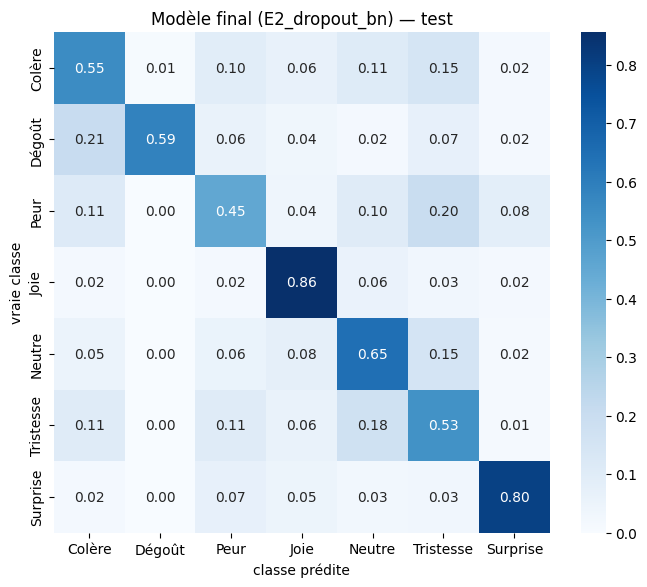

Confusions les plus fréquentes :
  Dégoût prédit Colère : 21% des cas
  Peur prédit Tristesse : 20% des cas
  Tristesse prédit Neutre : 18% des cas
  Neutre prédit Tristesse : 15% des cas
  Colère prédit Tristesse : 15% des cas


In [ ]:
proba_test = rapport(modele_final, X_test, y_test, f'Modèle final ({nom_final}) — test')

In [ ]:
lignes = []
for nom in ['MLP', 'E0_cnn_base', nom_final]:
    acc, f1, _ = evaluer(modeles[nom], X_test, y_test)
    lignes.append({'modèle': nom, 'accuracy test': acc, 'macro-F1 test': f1})
pd.DataFrame(lignes).set_index('modèle').round(3)

,accuracy test,macro-F1 test
modèle,,
MLP,0.407,0.326
E0_cnn_base,0.555,0.525
E2_dropout_bn,0.655,0.643


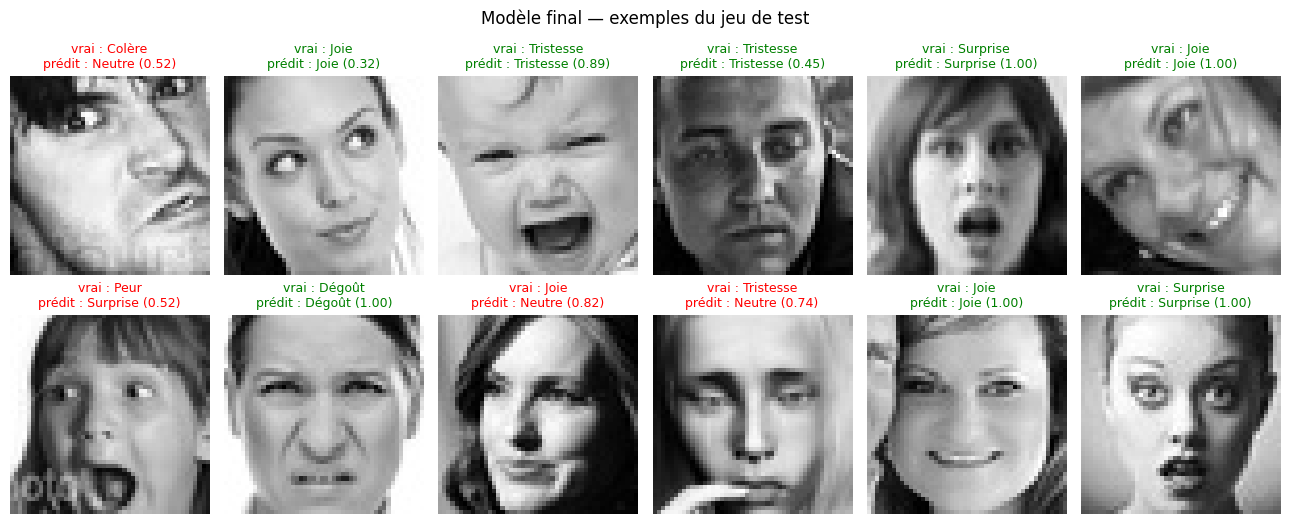

In [ ]:
afficher(X_test, y_test, proba_test, np.random.default_rng(1).choice(len(X_test), 12, replace=False),
         'Modèle final — exemples du jeu de test')

>**Analyse :** Sur le jeu de test, le modèle final E2 obtient une accuracy de 0,655 et un macro-F1 de 0,643. Ces résultats sont proches, et même légèrement supérieurs, à ceux obtenus sur la validation (0,647 et 0,623). Le modèle généralise donc correctement sur des images qui n'ont pas été utilisées pour choisir le modèle.

Le modèle final améliore nettement les résultats par rapport au MLP, qui obtient 0,407 d'accuracy, et au CNN de base, qui obtient 0,555. Les classes les mieux reconnues sont Joie et Surprise, avec des F1-scores respectifs de 0,841 et 0,794. Peur et Tristesse restent les classes les plus difficiles.

Les principales confusions concernent notamment Peur et Tristesse, ainsi que Tristesse et Neutre. Malgré ces erreurs, les résultats montrent que l'utilisation d'un CNN avec Dropout et Batch Normalization améliore fortement la reconnaissance des expressions faciales par rapport au modèle de référence.

---
# Conclusion

Dans ce projet, nous avons étudié plusieurs modèles pour la classification des expressions faciales à partir d’images 48×48. Le MLP a donné des performances assez limitées, avec une accuracy d’environ 0,41. Le CNN de base a permis d’obtenir de meilleurs résultats, mais il présentait un fort surapprentissage.

Nous avons ensuite testé plusieurs améliorations comme le Dropout, la Batch Normalization, la Data Augmentation, l’augmentation du nombre de filtres et la pondération des classes. Ces expériences nous ont permis de comparer leurs effets sur les performances et sur la généralisation du modèle.

Finalement, nous avons choisi le modèle E2 avec Dropout et Batch Normalization, car il obtenait le meilleur macro-F1 sur le jeu de validation. Sur le jeu de test, ce modèle atteint une accuracy de 0,655 et un macro-F1 de 0,643.

Les résultats montrent que les CNN sont bien adaptés à la reconnaissance des expressions faciales. Cependant, certaines expressions comme la peur et la tristesse restent difficiles à distinguer. Les performances pourraient encore être améliorées avec un modèle plus profond, davantage de données ou des techniques de Data Augmentation mieux adaptées.